## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [7]:
!pip install folium
!pip install kneed
!pip install yellowbrick
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [8]:
import numpy as np
import pandas as pd

In [9]:
df_marketing_campaign = pd.read_csv(r"D:\L-NMPTDL&AI\NMPTDL&AI\Bài học\Clustering\Week7_24696171_HuynhGiaPhat\data\marketing_campaign.csv")

In [10]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [11]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [12]:
# TODO: Xử lý dữ liệu khuyết cho Income bằng cách thêm mean
customer_data['Income'] =customer_data['Income'].fillna(
    customer_data['Income'].mean()
)

#### A3. Feature engineering

In [13]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [14]:
# Trích xuất tuổi từ đặc trưng năm sinh
customer_data['Age'] = 2022 - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [15]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], dayfirst=True)
now = datetime.datetime.now()
customer_data['Enroll_days'] = (now - customer_data['Dt_Customer']).dt.days

- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [16]:
# Chuyển Marital_Status thành số người lớn
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
}

customer_data['Marital_Status'] = customer_data['Marital_Status'].map(marital_map)

# Tính tổng số người trong gia đình
customer_data['Fam_Size'] = (
    customer_data['Marital_Status']
    + customer_data['Kidhome']
    + customer_data['Teenhome']
)

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [17]:
# Num_Accepted = AcceptedCmp1 + AcceptedCmp2 + ...
customer_data['Num_Accepted'] = (
    customer_data['AcceptedCmp1'] +
    customer_data['AcceptedCmp2'] +
    customer_data['AcceptedCmp3'] +
    customer_data['AcceptedCmp4'] +
    customer_data['AcceptedCmp5']
)

In [18]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
customer_data['MntTotal'] = (
    customer_data['MntWines'] +
    customer_data['MntFruits'] +
    customer_data['MntMeatProducts'] +
    customer_data['MntFishProducts'] +
    customer_data['MntSweetProducts'] +
    customer_data['MntGoldProds']
)

#### A4. Phân tích EDA

In [19]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,53.194196,4838.582143,2.595089,0.297768,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,26.000000,4485.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000,4665.750000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,52.000000,4840.500000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,63.000000,5014.000000,3.000000,0.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,129.000000,5184.000000,5.000000,4.000000,2525.000000
std,11.984069,0.478728,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.906959,0.678381,602.249288


In [20]:
%pip install --no-cache-dir matplotlib==3.10.7 seaborn

Note: you may need to restart the kernel to use updated packages.


In [21]:
%pip install --force-reinstall --no-deps matplotlib==3.10.7

  Using cached matplotlib-3.10.7-cp313-cp313-win_amd64.whl.metadata (11 kB)
Using cached matplotlib-3.10.7-cp313-cp313-win_amd64.whl (8.1 MB)
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.7
    Uninstalling matplotlib-3.10.7:
      Successfully uninstalled matplotlib-3.10.7
Note: you may need to restart the kernel to use updated packages.


In [22]:
import matplotlib
print(matplotlib.__version__)

import matplotlib.pyplot as plt
import seaborn as sns

3.10.7


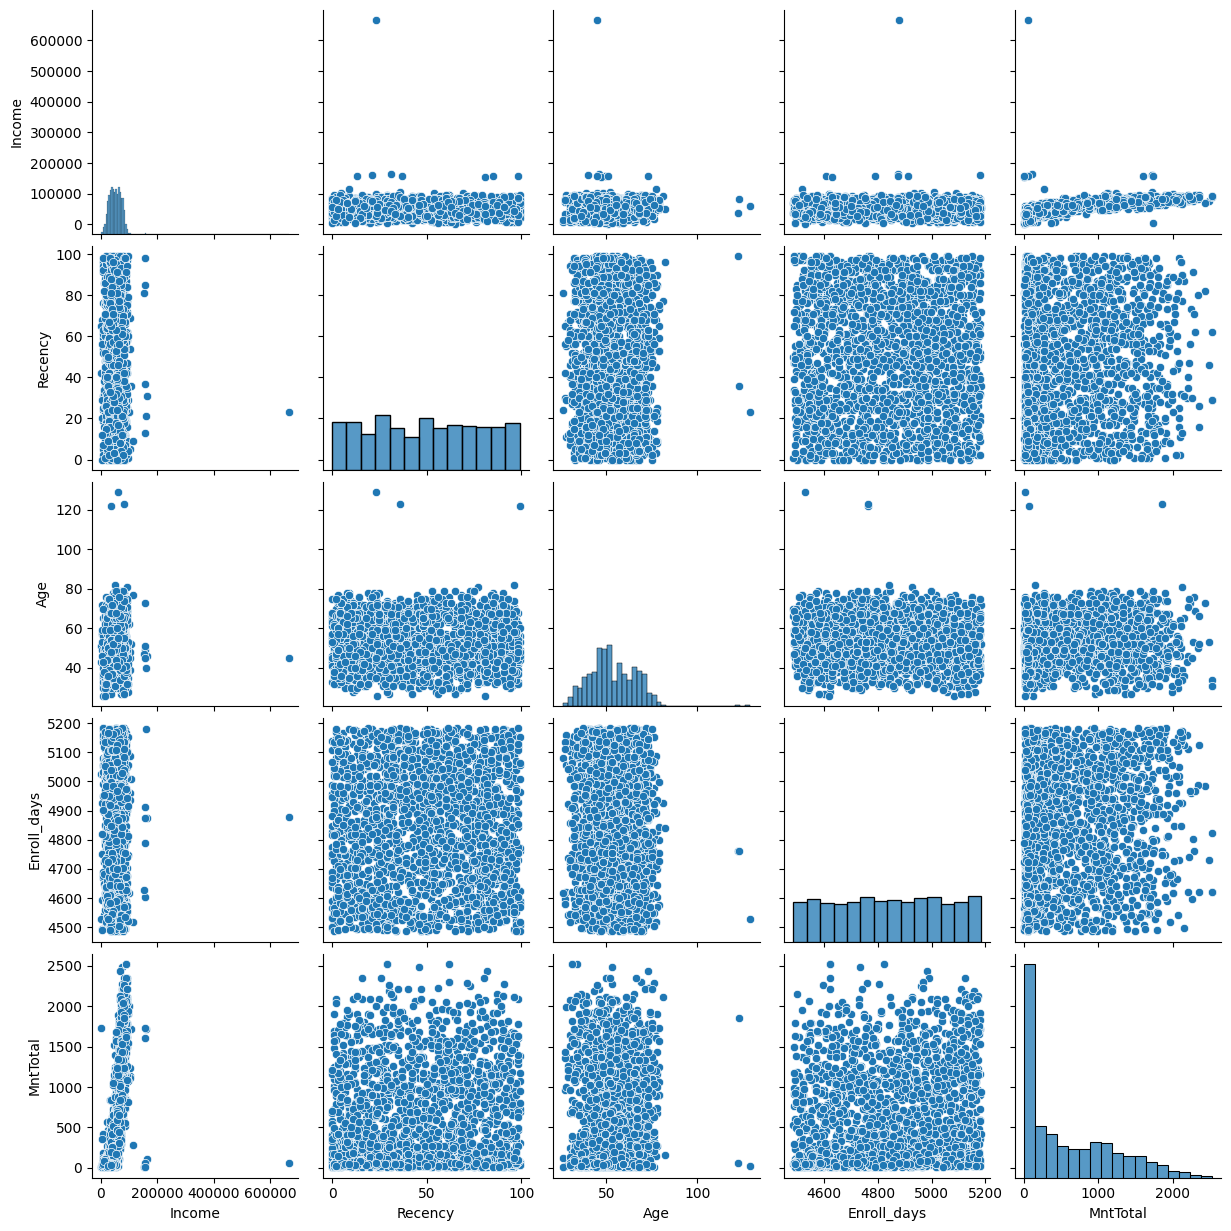

In [23]:
import seaborn as sns
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
# TODO - vẽ pair plot
sns.pairplot(customer_data[plot_cols])
plt.show()

In [24]:
# TODO - xử lý nhiễu (nếu có)
for col in plot_cols:
    Q1 = customer_data[col].quantile(0.25)
    Q3 = customer_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    customer_data[col] = customer_data[col].clip(lower, upper)


In [25]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [26]:
# TODO
customer_data = pd.get_dummies(
    customer_data,
    columns=['Education', 'Marital_Status'],
    dtype=int
)

**Chuẩn hoá các thuộc tính kiểu số**

In [27]:
# TODO
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = customer_data.select_dtypes(include='number').columns

customer_data[num_cols] = scaler.fit_transform(customer_data[num_cols])

In [28]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,51875.150461,49.109375,2.325000,4.084821,2.662054,5.790179,5.316518,53.147768,4838.582143,2.595089,605.779408
std,20936.079938,28.962453,1.932238,2.778714,2.923101,3.250958,2.426645,11.771725,202.122512,0.906959,602.189559
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,4485.000000,1.000000,5.000000
25%,35538.750000,24.000000,1.000000,2.000000,0.000000,3.000000,3.000000,45.000000,4665.750000,2.000000,68.750000
50%,51741.500000,49.000000,2.000000,4.000000,2.000000,5.000000,6.000000,52.000000,4840.500000,3.000000,396.000000
75%,68289.750000,74.000000,3.000000,6.000000,4.000000,8.000000,7.000000,63.000000,5014.000000,3.000000,1045.500000
max,117416.250000,99.000000,15.000000,27.000000,28.000000,13.000000,20.000000,90.000000,5184.000000,5.000000,2510.625000


#### A6. Phân cụm KMeans

In [29]:
from sklearn.cluster import KMeans

# Chọn các cột số
X = customer_data.select_dtypes(include='number').drop(
    columns=['Cluster'], errors='ignore'
)

# Phân cụm thành 4 nhóm
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_data['Cluster'] = kmeans.fit_predict(X)

# Số lượng khách hàng trong mỗi cụm
print(customer_data['Cluster'].value_counts())

Cluster
0    1005
3     626
1     472
2     137
Name: count, dtype: int64


c:\Users\huynh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\huynh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\huynh\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\huynh\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Phương pháp Elbow: ước lượng số cụm

c:\Users\huynh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\huynh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\huynh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\huynh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

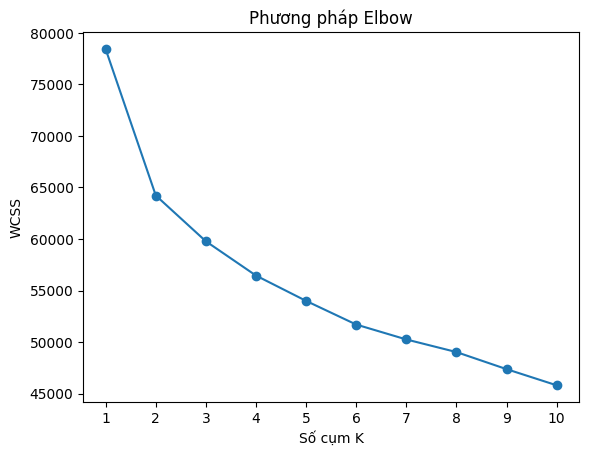

In [30]:
# TODO - vẽ biểu đồ elbow để ước lượng số cụm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = customer_data.select_dtypes(include='number').drop(
    columns=['Cluster'], errors='ignore'
)

wcss = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(K, wcss, marker='o')
plt.xlabel('Số cụm K')
plt.ylabel('WCSS')
plt.title('Phương pháp Elbow')
plt.xticks(K)
plt.show()

Sử dụng thư viện yellowbrick

**Phân cụm từ kết quả của phương pháp Elbow**

In [51]:
# TODO
from sklearn.cluster import KMeans
# Phân cụm từ kết quả của phương pháp Elbow
k_optimal = 4  # Thay bằng số cụm tối ưu từ biểu đồ Elbow

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
customer_data['Cluster'] = kmeans.fit_predict(X)

# Hiển thị số lượng khách hàng trong mỗi cụm
print(customer_data['Cluster'].value_counts())

Cluster
0    1005
3     626
1     472
2     137
Name: count, dtype: int64


c:\Users\huynh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Lấy dữ liệu số, bỏ cột Cluster khỏi đầu vào
X = customer_data.select_dtypes(include='number').drop(
    columns=['Cluster'], errors='ignore'
)

# Giảm xuống 2 thành phần chính
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Kích thước sau PCA:", X_pca.shape)
print("Tỷ lệ phương sai:", pca.explained_variance_ratio_)
print("Tổng phương sai giải thích:", pca.explained_variance_ratio_.sum())

Kích thước sau PCA: (2240, 2)
Tỷ lệ phương sai: [0.23458995 0.08255748]
Tổng phương sai giải thích: 0.3171474346506589


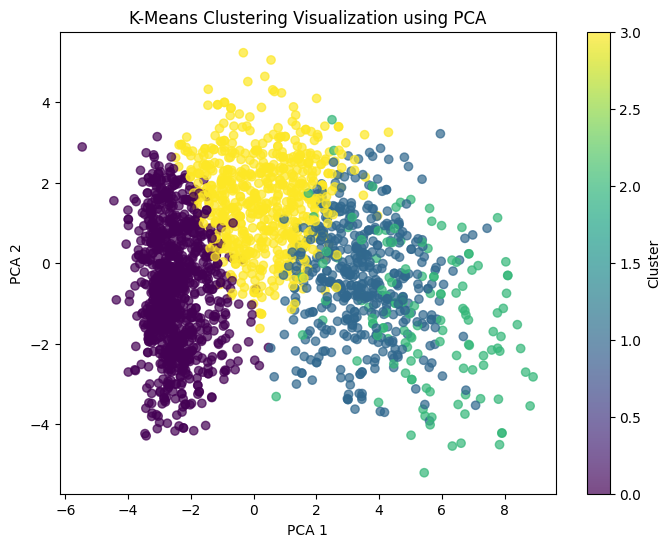

In [39]:
# Lấy nhãn cụm từ K-Means
clusters = customer_data['Cluster']

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clustering Visualization using PCA')
plt.colorbar(label='Cluster')
plt.show()

In [52]:
# Biến đổi dữ liệu sang không gian 2 chiều PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(X_pca.shape)

(2240, 2)


**Trực quan hoá kết quả phân cụm**

In [47]:
def visualize_cluster_result(scores, labels):
    fig1, (axes) = plt.subplots(figsize=(8,8))

    scat_1 = sns.scatterplot(
        x=scores[:,0],
        y=scores[:,1],
        hue=labels,
        ax=axes,
        palette='Set1',
        legend='full'
    )

    plt.show()

#### Phân tích kết quả phân cụm (KMeans)

In [54]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = customer_data['Cluster']

kmean_df.head()

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_1,Marital_Status_2,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,-0.985345,0.299208,-0.825218,-0.929894,2012-09-04,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,0.349414,1.409304,2.510890,-0.550785,0.693904,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,2.388846,1.007064,1.531185,-1.759115,-0.439037,1.679615,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,1.346874,-1.346874,1
2174,-1.235733,-0.264251,1.032559,0.906934,2014-03-08,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-0.168236,-1.110409,-0.568720,-1.166125,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,1.261969,-1.190545,0.446548,-0.439037,-0.961340,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,1.346874,-1.346874,0
4141,-0.317643,0.942978,-0.825218,-0.929894,2013-08-21,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,-0.685887,1.409304,-0.226541,1.295237,-0.542647,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,0.327318,-0.205773,-0.656283,-0.439037,0.282733,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.742460,0.742460,1
6182,1.268149,-1.205325,1.032559,-0.929894,2014-02-10,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.168236,-0.750450,-0.910898,-0.550785,0.281720,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,-1.287080,-1.061881,0.446548,-0.439037,-0.918154,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.742460,0.742460,0
5324,1.017761,0.306613,1.032559,-0.929894,2014-01-19,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,1.384715,0.329427,0.115638,0.064556,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,-1.032175,-0.953012,0.446548,-0.439037,-0.305253,-0.315684,-0.157171,-1.006270,-0.444816,1.899751,-0.742460,0.742460,0


In [55]:
def visualize_cluster_distribution(labels):
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]

    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count,
            explode=[0.05]*len(ulabels),
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

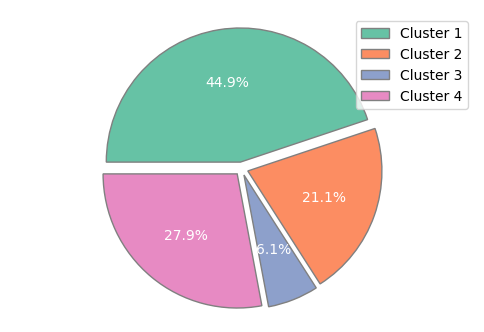

In [57]:
visualize_cluster_distribution(kmean_df['Cluster'])

**Phân tích đa biến + kết quả phân cụm**

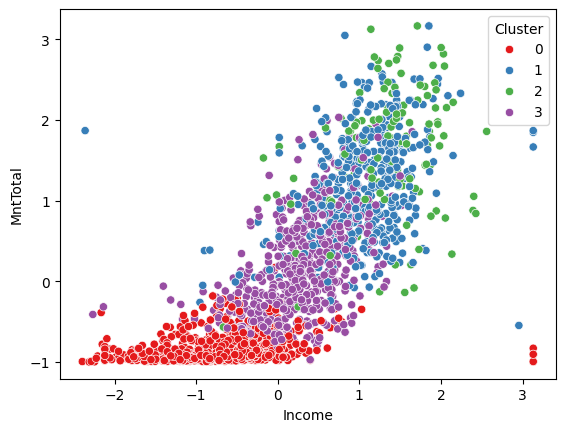

In [58]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
sns.scatterplot(data=kmean_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1')
plt.show()

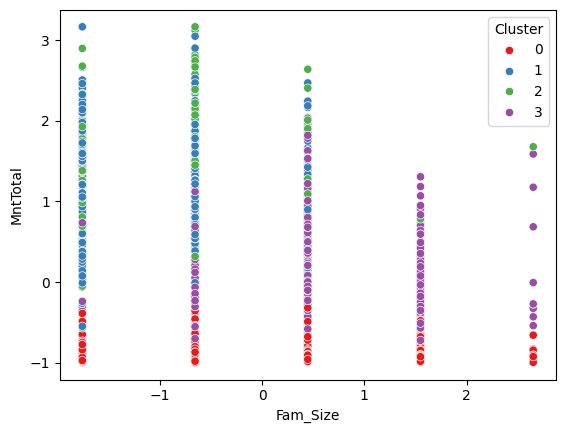

In [60]:
# đặc trưng Fam_Size và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
sns.scatterplot(data=kmean_df, x='Fam_Size', y='MntTotal', hue='Cluster', palette='Set1')
plt.show()

**Phân tích danh mục mua hàng**

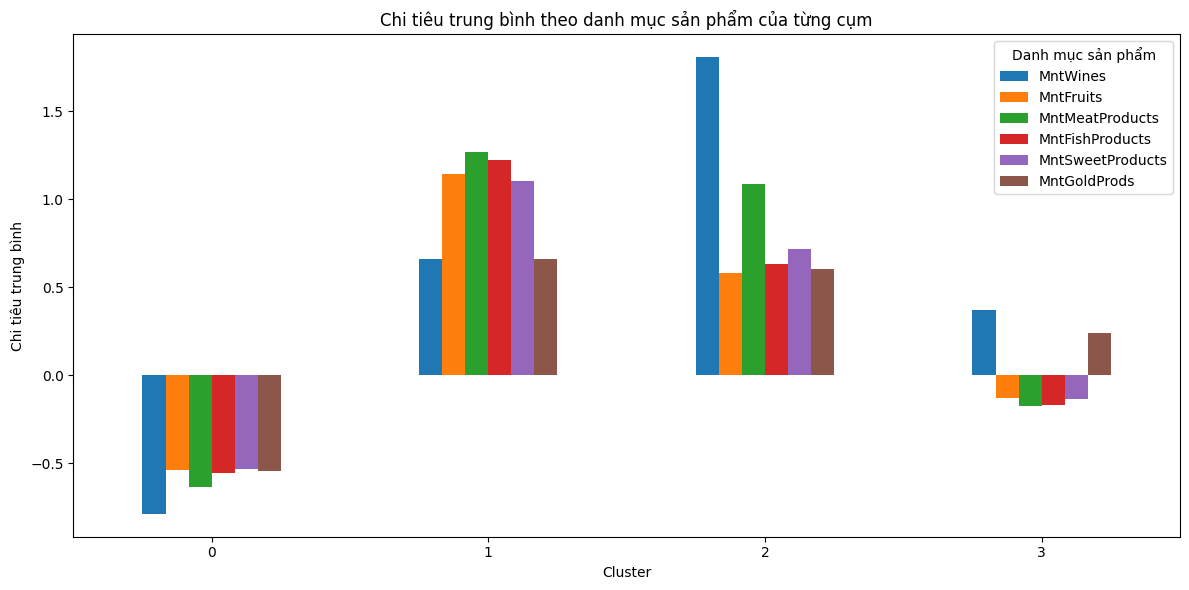

In [61]:
# TODO
# Phân tích danh mục mua hàng theo cụm
mnt_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

kmean_df.groupby('Cluster')[mnt_cols].mean().plot(
    kind='bar', figsize=(12, 6)
)

plt.title('Chi tiêu trung bình theo danh mục sản phẩm của từng cụm')
plt.xlabel('Cluster')
plt.ylabel('Chi tiêu trung bình')
plt.xticks(rotation=0)
plt.legend(title='Danh mục sản phẩm')
plt.tight_layout()
plt.show()

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [62]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

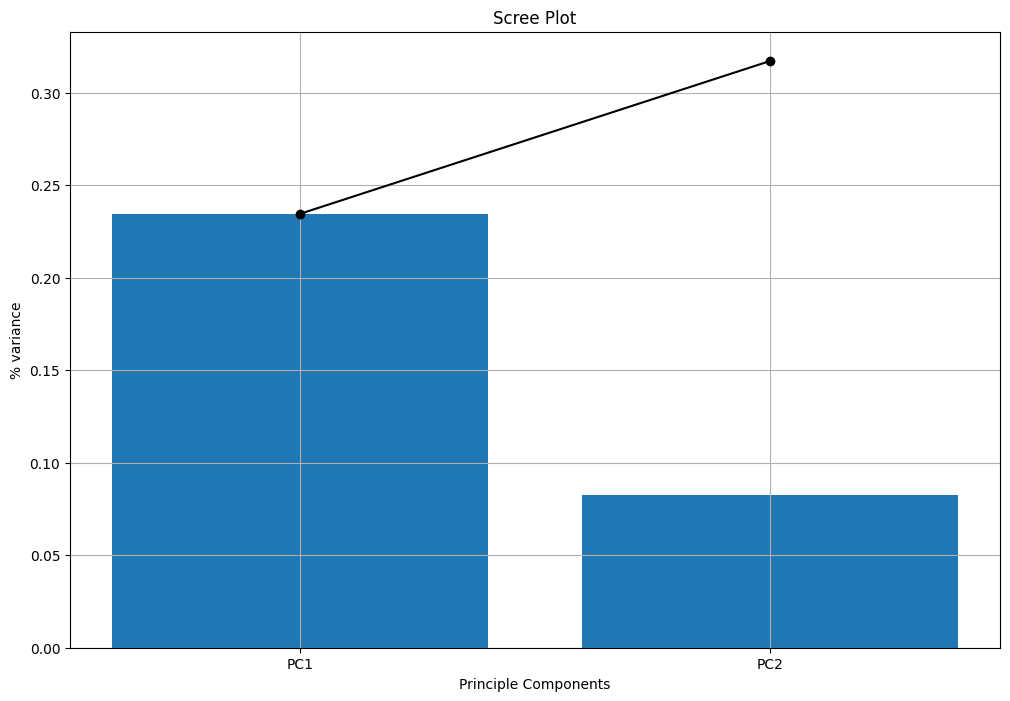

In [64]:
scree_plot(pca, [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))])

In [66]:
# biến đổi df sang không gian pca 4 chiều
# TODO
pca_4d = PCA(n_components=4)
pca_transformed_4d = pca_4d.fit_transform(df)

In [ ]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = kmean.labels_
kmean_pca_df.head()

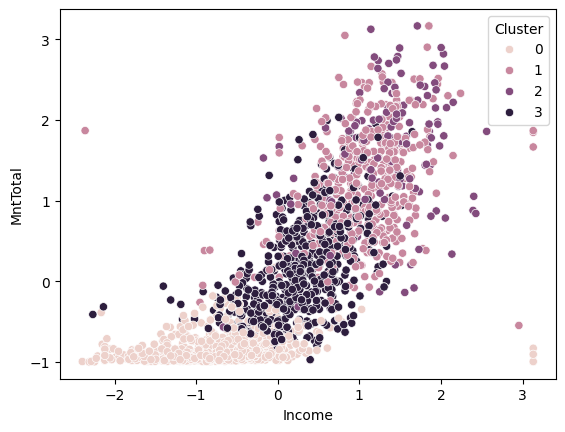

In [70]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
sns.scatterplot(data=kmean_df, x='Income', y='MntTotal', hue='Cluster')
plt.show()

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [72]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X)

dbscan_df = customer_data.copy()
dbscan_df['Cluster'] = labels

dbscan_df.head()

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_1,Marital_Status_2,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,-0.985345,0.299208,-0.825218,-0.929894,2012-09-04,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,0.349414,1.409304,2.510890,-0.550785,0.693904,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,2.388846,1.007064,1.531185,-1.759115,-0.439037,1.679615,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,1.346874,-1.346874,-1
2174,-1.235733,-0.264251,1.032559,0.906934,2014-03-08,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-0.168236,-1.110409,-0.568720,-1.166125,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,1.261969,-1.190545,0.446548,-0.439037,-0.961340,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,1.346874,-1.346874,-1
4141,-0.317643,0.942978,-0.825218,-0.929894,2013-08-21,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,-0.685887,1.409304,-0.226541,1.295237,-0.542647,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,0.327318,-0.205773,-0.656283,-0.439037,0.282733,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.742460,0.742460,-1
6182,1.268149,-1.205325,1.032559,-0.929894,2014-02-10,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.168236,-0.750450,-0.910898,-0.550785,0.281720,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,-1.287080,-1.061881,0.446548,-0.439037,-0.918154,-0.315684,-0.157171,0.993769,-0.444816,-0.526385,-0.742460,0.742460,-1
5324,1.017761,0.306613,1.032559,-0.929894,2014-01-19,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,1.384715,0.329427,0.115638,0.064556,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612,-1.032175,-0.953012,0.446548,-0.439037,-0.305253,-0.315684,-0.157171,-1.006270,-0.444816,1.899751,-0.742460,0.742460,-1


**Sử dụng knee plot để ước lượng eps**

In [73]:
len(df.columns)

11

In [74]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    plt.plot(distances)
    
    return distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

In [75]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

### B. Dữ liệu taxi 

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('data/taxi_data.csv')
df.head()

**Biểu diễn giá trị toạ độ trên bản đồ**

In [ ]:
import folium, re

In [ ]:
X = df[['LAT','LON']].values
m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='Stamen Toner', zoom_start=10)

In [ ]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

In [ ]:
# Knee plot để ước lượng eps

In [ ]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [ ]:
# Sử dụng DBSCAN để phân cụm

In [ ]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:,0].mean(),X[:,1].mean()],tiles='Stamen Toner',zoom_start=8.5)
    for _,row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT,row.LON],
            radius=5,
            popup=row[cluster_column],
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m